# English to Manipuri Machine Translation

Encoder-decoder sequence-to-sequence model using the dataset columns `eng_src` and `meti_tgt`.

This notebook trains for exactly **20 epochs**, reports training/validation loss, computes BLEU scores, and provides a function to translate English input sentences.

## 1. Setup

If any package is missing, install it in a separate cell, for example:

```python
!pip install tensorflow pandas openpyxl matplotlib
```

In [1]:
from pathlib import Path
from collections import Counter
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 2. Configuration

In [3]:
DATA_PATH = Path('eng_mni_fresh_daatsets.xlsx')
SOURCE_COL = 'eng_src'
TARGET_COL = 'meti_tgt'

EPOCHS = 20
BATCH_SIZE = 64
MAX_SOURCE_LEN = 40
MAX_TARGET_LEN = 45
SOURCE_VOCAB_SIZE = 12000
TARGET_VOCAB_SIZE = 12000
EMBED_DIM = 256
LATENT_DIM = 512

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Could not find {DATA_PATH.resolve()}\n'
        'Place eng_mni_fresh_daatsets.xlsx in the same folder as this notebook, '
        'or update DATA_PATH above.'
    )

## 3. Load and Clean the Dataset

In [4]:
df = pd.read_excel(DATA_PATH)
print('Dataset shape:', df.shape)
print('Columns:', list(df.columns))

missing = {SOURCE_COL, TARGET_COL} - set(df.columns)
if missing:
    raise ValueError(f'Missing expected column(s): {missing}')

df = df[[SOURCE_COL, TARGET_COL]].copy()
df[SOURCE_COL] = df[SOURCE_COL].astype(str).str.strip()
df[TARGET_COL] = df[TARGET_COL].astype(str).str.strip()
df = df[(df[SOURCE_COL] != '') & (df[TARGET_COL] != '')]
df = df.drop_duplicates().reset_index(drop=True)


df['target_text'] = '[start] ' + df[TARGET_COL] + ' [end]'

print('Cleaned shape:', df.shape)
df.head()

Dataset shape: (13953, 3)
Columns: ['eng_src', 'meti_tgt', 'mni_latn']
Cleaned shape: (13862, 3)


,eng_src,meti_tgt,target_text
0,Armed men abduct children and staff at a Catho...,ꯅꯥꯏꯖꯦꯔꯤꯌꯥꯗ ꯂꯩꯕ ꯀꯦꯊꯣꯂꯤꯛ ꯁ꯭ꯀꯨꯜ ꯑꯃꯗ ꯈꯨꯠꯂꯥꯏ ꯄꯥꯏꯕ ꯅ...,[start] ꯅꯥꯏꯖꯦꯔꯤꯌꯥꯗ ꯂꯩꯕ ꯀꯦꯊꯣꯂꯤꯛ ꯁ꯭ꯀꯨꯜ ꯑꯃꯗ ꯈꯨꯠꯂꯥ...
1,Armed men attacked a Catholic boarding school ...,ꯏꯔꯥꯏ ꯅꯨꯃꯤꯠꯀꯤ ꯑꯉꯟꯕꯗ ꯈꯨꯠꯂꯥꯏ ꯄꯥꯏꯕ ꯅꯨꯄꯥꯁꯤꯡꯅ ꯅꯥꯏꯖꯦꯔ...,[start] ꯏꯔꯥꯏ ꯅꯨꯃꯤꯠꯀꯤ ꯑꯉꯟꯕꯗ ꯈꯨꯠꯂꯥꯏ ꯄꯥꯏꯕ ꯅꯨꯄꯥꯁꯤꯡ...
2,The latest in a spate of abductions in Africa'...,ꯑꯐ꯭ꯔꯤꯀꯥꯒꯤ ꯈ꯭ꯋꯥꯏꯗꯒꯤ ꯃꯤꯁꯤꯡ ꯌꯥꯝꯕ ꯂꯩꯕꯥꯛ ꯑꯁꯤꯗ ꯃꯊꯪ-ꯃ...,[start] ꯑꯐ꯭ꯔꯤꯀꯥꯒꯤ ꯈ꯭ꯋꯥꯏꯗꯒꯤ ꯃꯤꯁꯤꯡ ꯌꯥꯝꯕ ꯂꯩꯕꯥꯛ ꯑꯁ...
3,The attack and abductions took place at St. Ma...,ꯂꯥꯟꯗꯥꯕ ꯑꯃꯁꯨꯡ ꯃꯤ ꯐꯥꯈꯤꯕ ꯑꯁꯤ ꯑꯒ꯭ꯋꯥꯔꯥ ꯂꯣꯀꯦꯜ ꯒꯕꯔꯟꯃꯦ...,[start] ꯂꯥꯟꯗꯥꯕ ꯑꯃꯁꯨꯡ ꯃꯤ ꯐꯥꯈꯤꯕ ꯑꯁꯤ ꯑꯒ꯭ꯋꯥꯔꯥ ꯂꯣꯀꯦ...
4,He did not disclose the number of students and...,ꯃꯍꯥꯛꯅ ꯐꯥꯈꯤꯕ ꯃꯍꯩꯔꯣꯏ ꯑꯃꯁꯨꯡ ꯊꯧꯃꯤꯁꯤꯡꯒꯤ ꯃꯁꯤꯡ ꯑꯗꯨ ꯐꯣ...,[start] ꯃꯍꯥꯛꯅ ꯐꯥꯈꯤꯕ ꯃꯍꯩꯔꯣꯏ ꯑꯃꯁꯨꯡ ꯊꯧꯃꯤꯁꯤꯡꯒꯤ ꯃꯁꯤ...


## 4. Train, Validation, and Test Split

In [5]:
indices = np.random.default_rng(SEED).permutation(len(df))
train_end = int(0.80 * len(indices))
val_end = int(0.90 * len(indices))

train_df = df.iloc[indices[:train_end]].reset_index(drop=True)
val_df = df.iloc[indices[train_end:val_end]].reset_index(drop=True)
test_df = df.iloc[indices[val_end:]].reset_index(drop=True)

print('Train:', train_df.shape)
print('Validation:', val_df.shape)
print('Test:', test_df.shape)

Train: (11089, 3)
Validation: (1386, 3)
Test: (1387, 3)


## 5. Tokenization and Vectorization

In [6]:
source_vectorizer = layers.TextVectorization(
    max_tokens=SOURCE_VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_SOURCE_LEN,
    standardize='lower_and_strip_punctuation',
)


target_vectorizer = layers.TextVectorization(
    max_tokens=TARGET_VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_TARGET_LEN,
    standardize=None,
)

source_vectorizer.adapt(train_df[SOURCE_COL].values)
target_vectorizer.adapt(train_df['target_text'].values)

source_vocab = source_vectorizer.get_vocabulary()
target_vocab = target_vectorizer.get_vocabulary()
target_index_lookup = dict(enumerate(target_vocab))

print('Source vocab size:', len(source_vocab))
print('Target vocab size:', len(target_vocab))
print('First target tokens:', target_vocab[:10])

Source vocab size: 12000
Target vocab size: 12000
First target tokens: ['', '[UNK]', np.str_('[start]'), np.str_('[end]'), np.str_('ꯑꯃꯁꯨꯡ'), np.str_('ꯑꯩ'), np.str_('ꯑꯁꯤ'), np.str_('ꯑꯗꯨ'), np.str_('ꯇꯣꯝ'), np.str_('ꯍꯥꯏꯅ')]


## 6. Build `tf.data` Pipelines

In [7]:
def vectorize_batch(source_text, target_text):
    source_tokens = source_vectorizer(source_text)
    target_tokens = target_vectorizer(target_text)

    decoder_input = target_tokens[:, :-1]
    decoder_target = target_tokens[:, 1:]

    # Mask padded positions so loss/accuracy ignore zero padding.
    sample_weight = tf.cast(decoder_target != 0, tf.float32)
    return (source_tokens, decoder_input), decoder_target, sample_weight


def make_dataset(frame, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((frame[SOURCE_COL].values, frame['target_text'].values))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(frame), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).map(vectorize_batch, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

for batch in train_ds.take(1):
    print('Encoder input:', batch[0][0].shape)
    print('Decoder input:', batch[0][1].shape)
    print('Decoder target:', batch[1].shape)
    print('Sample weights:', batch[2].shape)

Encoder input: (64, 40)
Decoder input: (64, 44)
Decoder target: (64, 44)
Sample weights: (64, 44)


## 7. Encoder-Decoder Model

In [8]:
encoder_inputs = keras.Input(shape=(None,), dtype='int64', name='encoder_inputs')
decoder_inputs = keras.Input(shape=(None,), dtype='int64', name='decoder_inputs')

source_embedding = layers.Embedding(len(source_vocab), EMBED_DIM, mask_zero=True, name='source_embedding')
target_embedding = layers.Embedding(len(target_vocab), EMBED_DIM, mask_zero=True, name='target_embedding')
encoder_lstm = layers.LSTM(LATENT_DIM, return_state=True, name='encoder_lstm')
decoder_lstm = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True, name='decoder_lstm')
dropout = layers.Dropout(0.3, name='decoder_dropout')
output_dense = layers.Dense(len(target_vocab), activation='softmax', name='target_token_probs')

encoder_embedded = source_embedding(encoder_inputs)
_, state_h, state_c = encoder_lstm(encoder_embedded)

decoder_embedded = target_embedding(decoder_inputs)
decoder_outputs, _, _ = decoder_lstm(decoder_embedded, initial_state=[state_h, state_c])
decoder_outputs = dropout(decoder_outputs)
decoder_outputs = output_dense(decoder_outputs)

model = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs, name='english_to_manipuri_seq2seq')
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    weighted_metrics=['sparse_categorical_accuracy'],
)
model.summary()

Model: "english_to_manipuri_seq2seq"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ source_embedding    │ (None, None, 256) │  3,072,000 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ target_embedding    │ (None, None, 256) │  3,072,000 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 512),     │  1,574,912 │ source_embedding… │
│                     │ (None, 512),      │            │ not_equal[0][0]   │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │  1,574,912 │ target_embedding… │
│                     │ 512), (None,      │            │ encoder_lstm[0][… │
│                     │ 512), (None,      │            │ encoder_lstm[0][… │
│                     │ 512)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dropout     │ (None, None, 512) │          0 │ decoder_lstm[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ target_token_probs  │ (None, None,      │  6,156,000 │ decoder_dropout[… │
│ (Dense)             │ 12000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,449,824 (58.94 MB)

 Trainable params: 15,449,824 (58.94 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Train for 20 Epochs

In [9]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        'best_eng_mni_seq2seq.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/20
173/174 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 6.8659 - sparse_categorical_accuracy: 0.1518
Epoch 1: val_loss improved from None to 5.32120, saving model to best_eng_mni_seq2seq.keras

Epoch 1: finished saving model to best_eng_mni_seq2seq.keras
174/174 ━━━━━━━━━━━━━━━━━━━━ 27s 124ms/step - loss: 6.3288 - sparse_categorical_accuracy: 0.1766 - val_loss: 5.3212 - val_sparse_categorical_accuracy: 0.2665
Epoch 2/20
173/174 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 5.6963 - sparse_categorical_accuracy: 0.2134
Epoch 2: val_loss improved from 5.32120 to 5.05647, saving model to best_eng_mni_seq2seq.keras

Epoch 2: finished saving model to best_eng_mni_seq2seq.keras
174/174 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - loss: 5.6860 - sparse_categorical_accuracy: 0.2166 - val_loss: 5.0565 - val_sparse_categorical_accuracy: 0.2927
Epoch 3/20
173/174 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 5.4577 - sparse_categorical_accuracy: 0.2270
Epoch 3: val_loss improved from 5.05647 to 4.93351, 

## 9. Loss and Accuracy Curves

,loss,sparse_categorical_accuracy,val_loss,val_sparse_categorical_accuracy
15,2.802234,0.410006,4.578913,0.335526
16,2.644305,0.434794,4.611059,0.336973
17,2.493938,0.459141,4.646461,0.337104
18,2.353904,0.482337,4.688154,0.333553
19,2.226990,0.504825,4.724473,0.334079


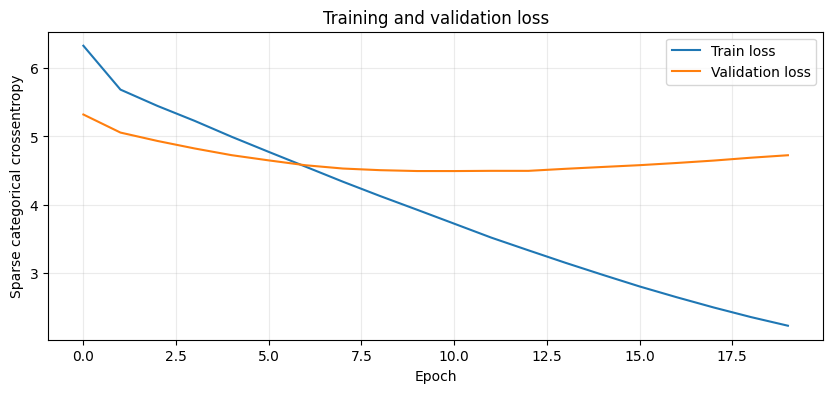

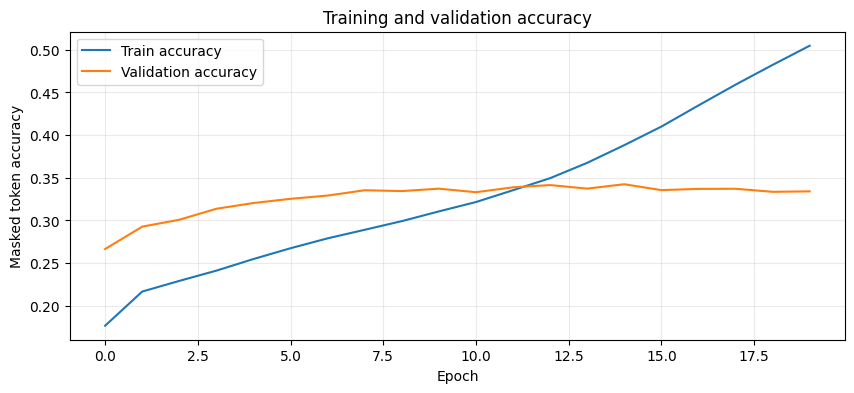

In [10]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

plt.figure(figsize=(10, 4))
plt.plot(history_df['loss'], label='Train loss')
plt.plot(history_df['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Sparse categorical crossentropy')
plt.title('Training and validation loss')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

if 'sparse_categorical_accuracy' in history_df:
    plt.figure(figsize=(10, 4))
    plt.plot(history_df['sparse_categorical_accuracy'], label='Train accuracy')
    plt.plot(history_df['val_sparse_categorical_accuracy'], label='Validation accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Masked token accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

## 10. Test Loss

In [11]:
test_metrics = model.evaluate(test_ds, return_dict=True)
test_metrics

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 4.6712 - sparse_categorical_accuracy: 0.3296


{'loss': 4.671192169189453, 'sparse_categorical_accuracy': 0.32959628105163574}

## 11. Translation Function

In [12]:
def translate(sentence, max_len=MAX_TARGET_LEN):
    """Greedy decoding from English text to Manipuri text."""
    source_tokens = source_vectorizer(tf.constant([sentence]))
    encoder_emb = source_embedding(source_tokens)
    _, h, c = encoder_lstm(encoder_emb)

    decoded_tokens = ['[start]']
    for _ in range(max_len - 1):
        decoder_text = ' '.join(decoded_tokens)
        decoder_tokens = target_vectorizer(tf.constant([decoder_text]))[:, :-1]
        decoder_emb = target_embedding(decoder_tokens)
        decoder_out, _, _ = decoder_lstm(decoder_emb, initial_state=[h, c])
        token_probs = output_dense(decoder_out)

        next_token_id = int(tf.argmax(token_probs[0, len(decoded_tokens) - 1, :], axis=-1).numpy())
        next_token = target_index_lookup.get(next_token_id, '[UNK]')

        if next_token == '[end]' or next_token == '':
            break
        decoded_tokens.append(next_token)

    return ' '.join(decoded_tokens[1:])


sample_sentence = test_df.iloc[0][SOURCE_COL]
print('English:', sample_sentence)
print('Reference Manipuri:', test_df.iloc[0][TARGET_COL])
print('Predicted Manipuri:', translate(sample_sentence))

English: I'm not dying.
Reference Manipuri: ꯑꯩ ꯁꯤꯔꯣꯏ꯫
Predicted Manipuri: ꯑꯩ [UNK]


## 12. BLEU Score Calculation

BLEU is reported as a percentage. BLEU-4 is the common MT score, while BLEU-1/2/3 help show partial n-gram quality.

In [16]:
def _ngrams(tokens, n):
    return Counter(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))


def corpus_bleu(references, hypotheses, max_n=4, smooth=1.0):
    clipped_counts = np.zeros(max_n, dtype=np.float64)
    total_counts = np.zeros(max_n, dtype=np.float64)
    ref_len = 0
    hyp_len = 0

    for ref, hyp in zip(references, hypotheses):
        ref_tokens = ref.split()
        hyp_tokens = hyp.split()
        ref_len += len(ref_tokens)
        hyp_len += len(hyp_tokens)

        for n in range(1, max_n + 1):
            ref_ngrams = _ngrams(ref_tokens, n)
            hyp_ngrams = _ngrams(hyp_tokens, n)
            total_counts[n - 1] += max(sum(hyp_ngrams.values()), 0)
            clipped_counts[n - 1] += sum(min(count, ref_ngrams[ng]) for ng, count in hyp_ngrams.items())

    if hyp_len == 0:
        return 0.0

    precisions = (clipped_counts + smooth) / (total_counts + smooth)
    log_precision = np.mean(np.log(precisions))
    brevity_penalty = 1.0 if hyp_len > ref_len else math.exp(1 - ref_len / max(hyp_len, 1))
    return 100.0 * brevity_penalty * math.exp(log_precision)


# Translate the full test set. For a faster quick check, use test_df.head(200) instead.
eval_df = test_df.copy()
eval_df['prediction'] = eval_df[SOURCE_COL].apply(translate)

bleu_scores = {
    'BLEU-1': corpus_bleu(eval_df[TARGET_COL], eval_df['prediction'], max_n=1),
    'BLEU-2': corpus_bleu(eval_df[TARGET_COL], eval_df['prediction'], max_n=2),
    'BLEU-3': corpus_bleu(eval_df[TARGET_COL], eval_df['prediction'], max_n=3),
    'BLEU-4': corpus_bleu(eval_df[TARGET_COL], eval_df['prediction'], max_n=4),
}

bleu_scores

{'BLEU-1': 8.011966469281194,
 'BLEU-2': 4.154061374126684,
 'BLEU-3': 2.0849652203894125,
 'BLEU-4': 0.9939582024912075}

## 13. Inspect Translations

In [17]:
preview = eval_df[[SOURCE_COL, TARGET_COL, 'prediction']].head(20)
display(preview)

# Try your own sentence here.
my_sentence = 'How are you?'
print('English:', my_sentence)
print('Manipuri:', translate(my_sentence))

,eng_src,meti_tgt,prediction
0,I'm not dying.,ꯑꯩ ꯁꯤꯔꯣꯏ꯫,ꯑꯩ [UNK]
1,Tom is laughing.,ꯇꯣꯝ ꯅꯣꯛ ꯏ꯫,ꯇꯣꯝ ꯂꯥꯏꯔꯥꯕꯥꯅꯦ꯫
2,Dept of Environment & Climate Change IMPACT SU...,ꯏꯟꯚꯥꯏꯔꯟꯃꯦꯟꯠ ꯑꯃꯁꯨꯡ ꯀ꯭ꯂꯥꯏꯃꯦꯠ ꯆꯦꯟꯖ ꯗꯤꯄꯥꯔꯠꯃꯦꯟꯠ ꯏꯝꯄ...,[UNK] [UNK] [UNK] [UNK] [UNK] [UNK] [UNK] [UNK...
3,That's our problem.,ꯑꯗꯣ ꯑꯩꯈꯣꯏꯒꯤ ꯑꯌꯦꯠꯄ ꯅꯠꯇꯦ꯫,ꯑꯗꯨ ꯑꯩꯈꯣꯏꯒꯤ [UNK]
4,The boys were quiet.,ꯅꯨꯄꯥ ꯒꯩꯗꯣ ꯇꯨꯃꯤꯟꯅ ꯂꯩ꯫,ꯅꯨꯄꯥ ꯁꯤꯡꯁꯦ [UNK]
5,Those comments came as the Ukrainian president...,ꯇ꯭ꯔꯝꯞ ꯑꯦꯗꯃꯤꯅꯤꯁꯇ꯭ꯔꯦꯁꯟꯒꯤ ꯃꯤꯍꯨꯠꯁꯤꯡ ꯁ꯭ꯇꯤꯕ ꯋꯤꯠꯀꯣꯐ ꯑ...,ꯏꯪ [UNK] ꯑꯦꯗꯤꯟꯕꯔꯒꯤ ꯂꯩꯈꯤꯗꯕꯒꯤ [UNK] [UNK] [UNK] ...
6,Auditing,ꯍꯤꯁꯥꯞ ꯌꯦꯡꯁꯤꯟꯕ,[UNK]
7,Accountability,ꯄꯥꯎꯈꯨꯝꯒꯗꯕ,[UNK] ꯑꯣꯏꯕꯥ
8,Tom's bus was late.,ꯇꯣꯝ ꯒꯤ ꯕꯁ ꯊꯦꯡꯑꯦ꯫,ꯇꯣꯝ ꯏꯔꯨ [UNK]
9,The boost came after Trump and the Pentagon re...,ꯇ꯭ꯔꯝꯞ ꯑꯃꯁꯨꯡ ꯄꯦꯟꯇꯒꯣꯟꯅ ꯇꯥꯏꯋꯥꯟꯅ ꯃꯈꯣꯏꯒꯤ ꯖꯤ.ꯗꯤ.ꯄꯤ.ꯒ...,[UNK] [UNK] [UNK] [UNK] [UNK] [UNK] [UNK] [UNK...


English: How are you?
Manipuri: ꯀꯥꯔꯥꯝ ꯍꯥꯏꯅꯥ ꯇꯧꯔꯤꯒꯦ ꯅꯪ?


## 14. Save Outputs

In [18]:
eval_df.to_excel('eng_mni_test_predictions.xlsx', index=False)
pd.DataFrame([bleu_scores | test_metrics]).to_excel('eng_mni_scores.xlsx', index=False)
model.save('final_eng_mni_seq2seq.keras')

print('Saved:')
print('- eng_mni_test_predictions.xlsx')
print('- eng_mni_scores.xlsx')
print('- final_eng_mni_seq2seq.keras')

Saved:
- eng_mni_test_predictions.xlsx
- eng_mni_scores.xlsx
- final_eng_mni_seq2seq.keras
